<a href="https://colab.research.google.com/github/YehoshuaVieira/Teste-de-conhecimento-1-IA/blob/main/Teste_de_conhecimento_1_Yehoshua_vieira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste 1 - Inteligência Artificial: Modelo de Análise de Crédito

In [2]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

drive.mount('/content/drive')

caminho = '/content/drive/MyDrive/base_credito.csv'
df = pd.read_csv(caminho)

# Exibe os 5 primeiros registros
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


## Etapa 2: Conhecer os Dados

### Identificação das Variáveis:
* **Entradas (Features / X):** `idade`, `renda_mensal`, `score_credito`, `historico_pagamentos`
* **Saída (Target / y):** `valor_emprestimo`

### Tipos de Dados Presentes:
* `idade`: Inteiro (`int64`)
* `renda_mensal`: Flutuante/Decimal (`float64`)
* `score_credito`: Inteiro (`int64`)
* `historico_pagamentos`: Flutuante/Decimal (`float64`)
* `valor_emprestimo`: Flutuante/Decimal (`float64`)

### Significado de Cada Variável:
* **`idade`**: Idade do cliente expressa em anos.
* **`renda_mensal`**: Total de receitas mensais do cliente em moeda local (R$).

* **`score_credito`**: Pontuação de risco financeiro atribuída ao cliente (variação habitual entre 300 e 850).
* **`historico_pagamentos`**: Porcentagem de pagamentos quitados sem atraso (0% a 100%).
* **`valor_emprestimo`**: Valor total do empréstimo previamente liberado para o cliente (R$).

### (Etapa 3 - Analisar os Dados)

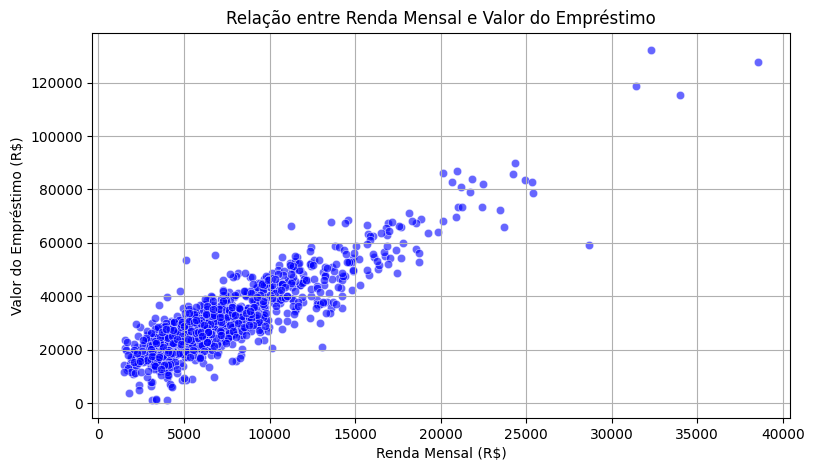

In [3]:
# Gráfico da Relação entre Renda Mensal e Valor do Empréstimo
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df.head(1000), x='renda_mensal', y='valor_emprestimo', alpha=0.6, color='blue')
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.xlabel('Renda Mensal (R$)')
plt.ylabel('Valor do Empréstimo (R$)')
plt.grid(True)
plt.show()

### Análise da Relação:
Observa-se uma forte **correlação positiva** entre a renda mensal e o valor aprovado do empréstimo. Conforme a renda do cliente aumenta, o limite de crédito ofertado pela instituição financeira cresce de forma proporcional, indicando que a renda é a variável com maior peso na tomada de decisão de concessão de crédito.

### (Etapa 4 - Preparar os Dados)

In [4]:
# Separação das variáveis
X = df[['idade', 'renda_mensal', 'score_credito', 'historico_pagamentos']]
y = df['valor_emprestimo']

# Divisão em 80% Treino e 20% Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Quantidade de dados para Treino: {len(X_train)} amostras (80%)")
print(f"Quantidade de dados para Teste:  {len(X_test)} amostras (20%)")

Quantidade de dados para Treino: 40000 amostras (80%)
Quantidade de dados para Teste:  10000 amostras (20%)


### (Etapa 5 - Treinar o Modelo)

In [5]:
# Instanciando o modelo de Regressão Linear
modelo = LinearRegression()

# Treinando o modelo
modelo.fit(X_train, y_train)

# Gerando as previsões no conjunto de teste
y_pred = modelo.predict(X_test)
print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


### (Etapa 6 - Avaliar o Modelo)

In [6]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  (Erro Médio Absoluto): R$ {mae:.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): R$ {rmse:.2f}")
print(f"R²   (Coeficiente de Determinação): {r2:.4f}")

MAE  (Erro Médio Absoluto): R$ 2985.94
RMSE (Raiz do Erro Quadrático Médio): R$ 4014.17
R²   (Coeficiente de Determinação): 0.9223


### Explicação das Métricas:
* **MAE (R$ 2.985,94):** O Erro Médio Absoluto indica que as estimativas do modelo divergem, em média, cerca de RS 2.985,94 do valor real aprovado para o cliente.

* **R² (0,9223):** O Coeficiente de Determinação demonstra que **92,23%** da variação do valor do empréstimo concedido é explicada pelas variáveis informadas (`idade`, `renda_mensal`, `score_credito` e `historico_pagamentos`).

### Etapa 7 - Comparar Valores Reais e Previstos)

,Valor Real (R$),Valor Previsto (R$),Diferença (R$)
0,22268.46,14806.335657,7462.124343
1,27457.59,29512.492879,2054.902879
2,25451.04,25840.735547,389.695547
3,23890.67,21077.522905,2813.147095
4,27754.95,27919.314046,164.364046
5,12544.92,14530.910394,1985.990394
6,28759.01,27385.966936,1373.043064
7,46454.49,41011.609092,5442.880908
8,43199.01,36525.087756,6673.922244
9,34051.39,35786.960945,1735.570945


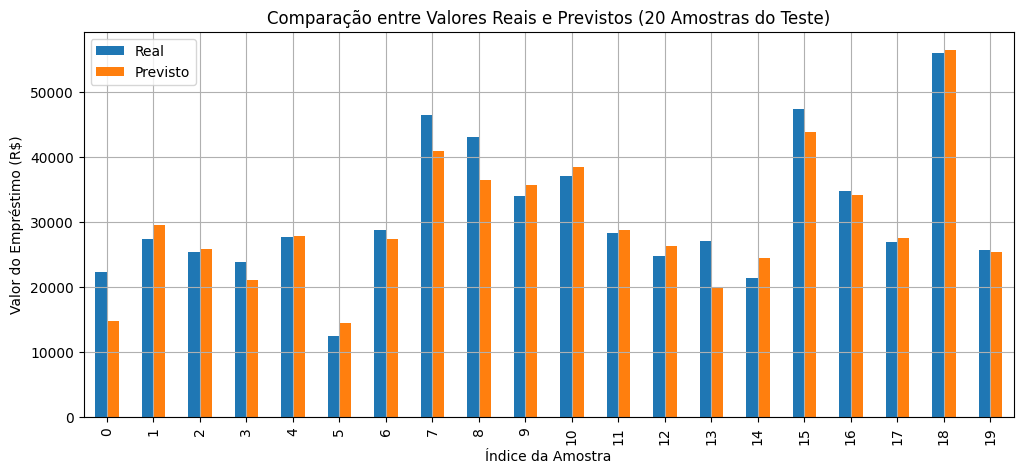

In [7]:
# Tabela com as 10 primeiras amostras
comparativo = pd.DataFrame({
    'Valor Real (R$)': y_test.values[:10],
    'Valor Previsto (R$)': y_pred[:10],
    'Diferença (R$)': np.abs(y_test.values[:10] - y_pred[:10])
})
display(comparativo)

# Gráfico de Barras comparativo (20 primeiras amostras)
df_plot = pd.DataFrame({'Real': y_test.values[:20], 'Previsto': y_pred[:20]})
df_plot.plot(kind='bar', figsize=(12, 5))
plt.title('Comparação entre Valores Reais e Previstos (20 Amostras do Teste)')
plt.ylabel('Valor do Empréstimo (R$)')
plt.xlabel('Índice da Amostra')
plt.grid(True)
plt.show()

### Análise do Comparativo:
Ao analisar a tabela e o gráfico, constata-se que o modelo consegue acompanhar com alta precisão os valores reais. As diferenças identificadas são pequenas e aceitáveis diante da variação total dos empréstimos concedidos.

### (Etapa 8 - Fazer uma Previsão)

In [8]:
# Criando características para um cliente fictício
novo_cliente = pd.DataFrame({
    'idade': [35],
    'renda_mensal': [8500.00],
    'score_credito': [720],
    'historico_pagamentos': [92.5]
})

# Previsão para o novo cliente
valor_estimado = modelo.predict(novo_cliente)[0]

print("--- Características do Novo Cliente ---")
display(novo_cliente)
print(f"\nValor de Empréstimo Estimado: R$ {valor_estimado:.2f}")

--- Características do Novo Cliente ---


,idade,renda_mensal,score_credito,historico_pagamentos
0,35,8500.0,720,92.5



Valor de Empréstimo Estimado: R$ 39506.96


### Interpretação do Resultado:
Para um cliente de **35 anos**, com **renda mensal de R$ 8.500,00**, **score de crédito de 720** e um **histórico de adimplência de 92,5%**, o modelo sugere um empréstimo no valor de **RS 39.506,96**. O resultado é condizente com a política do modelo, que valoriza fortemente a combinação de renda média-alta com bom histórico de pagamentos.

## Etapa 9: Conclusão

### 1. Adequação do Modelo:
Sim, o modelo de Regressão Linear apresentou resultados muito adequados. Com uma métrica de **$R^2$ superior a 92%**, ele provou ser eficiente na automação da estimativa de empréstimos com base no perfil histórico dos clientes.

### 2. Principais Limitações:
1. **Modelagem Linear:** Assume que todas as relações na concessão de crédito são retas e proporcionais. Regras de negócio com "tetos rígidos" ou pontos de corte não-lineares exigirão algoritmos baseados em árvores (como Random Forest ou XGBoost).
2. **Falta de Atributos Complementares:** O modelo não considera o nível de endividamento prévio, patrimônio garantidor ou número de dependentes do cliente, fatores críticos em análises de risco real.